In [ ]:
# ==============================
# IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


In [ ]:
customer_data = pd.read_csv("/content/travel.csv")


In [ ]:
# ==============================
# DATASET OVERVIEW
# ==============================

print("Shape of dataset:", customer_data.shape)
print("\nFirst 5 rows:")
print(customer_data.head())

print("\nDataset Information:")
customer_data.info()

print("\nColumns:")
print(customer_data.columns)

print("\nMissing Values:")
print(customer_data.isnull().sum())


Shape of dataset: (100000, 25)

First 5 rows:
   Unnamed: 0            date_time  site_name  posa_continent  \
0    24636210  2014-11-03 16:02:28         24               2   
1    19837144  2013-03-13 19:25:01         11               3   
2    13066459  2014-10-13 13:20:25          2               3   
3     4691082  2013-11-05 10:40:34         11               3   
4     4878884  2014-06-10 13:34:56          2               3   

   user_location_country  user_location_region  user_location_city  \
0                     77                   871               36643   
1                    205                   135               38749   
2                     66                   314               48562   
3                    205                   411               52752   
4                     66                   174               50644   

   orig_destination_distance  user_id  is_mobile  ...  srch_children_cnt  \
0                   456.1151   792280          0  ...             

In [ ]:
# ==============================
# DATA CLEANING
# ==============================

columns_to_drop = [
    'Unnamed: 0',
    'user_id',
    'date_time',
    'srch_ci',
    'srch_co',
    'hotel_cluster'  # remove for clustering
]

customer_data = customer_data.drop(columns=columns_to_drop, errors='ignore')

print("Shape after dropping columns:", customer_data.shape)


Shape after dropping columns: (100000, 19)


In [ ]:
# ==============================
# HANDLE MISSING VALUES
# ==============================

customer_data['orig_destination_distance'] = \
    customer_data['orig_destination_distance'].fillna(
        customer_data['orig_destination_distance'].median()
    )

print("\nMissing Values After Handling:")
print(customer_data.isnull().sum())



Missing Values After Handling:
site_name                    0
posa_continent               0
user_location_country        0
user_location_region         0
user_location_city           0
orig_destination_distance    0
is_mobile                    0
is_package                   0
channel                      0
srch_adults_cnt              0
srch_children_cnt            0
srch_rm_cnt                  0
srch_destination_id          0
srch_destination_type_id     0
is_booking                   0
cnt                          0
hotel_continent              0
hotel_country                0
hotel_market                 0
dtype: int64


In [ ]:
# ==============================
# FEATURE SELECTION
# ==============================

selected_features = [
    'orig_destination_distance',
    'is_mobile',
    'is_package',
    'channel',
    'srch_adults_cnt',
    'srch_children_cnt',
    'srch_rm_cnt',
    'cnt'
]

X = customer_data[selected_features]

print("Selected Features Shape:", X.shape)


Selected Features Shape: (100000, 8)


In [ ]:
# ====================================
# SCALING
# ====================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

k_range = range(2, 8)
sil_before = []

# Take sample if dataset is large
sample_size = 2000   # adjust if needed
if len(X_scaled) > sample_size:
    indices = np.random.choice(len(X_scaled), sample_size, replace=False)
    X_sample = X_scaled[indices]
else:
    X_sample = X_scaled

print("Silhouette Scores BEFORE PCA:\n")

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_sample)

    score = silhouette_score(X_sample, labels)
    sil_before.append(score)

    print(f"K = {k} → {score:.4f}")


Silhouette Scores BEFORE PCA:

K = 2 → 0.4146
K = 3 → 0.2619
K = 4 → 0.2887
K = 5 → 0.2608
K = 6 → 0.3219
K = 7 → 0.3060


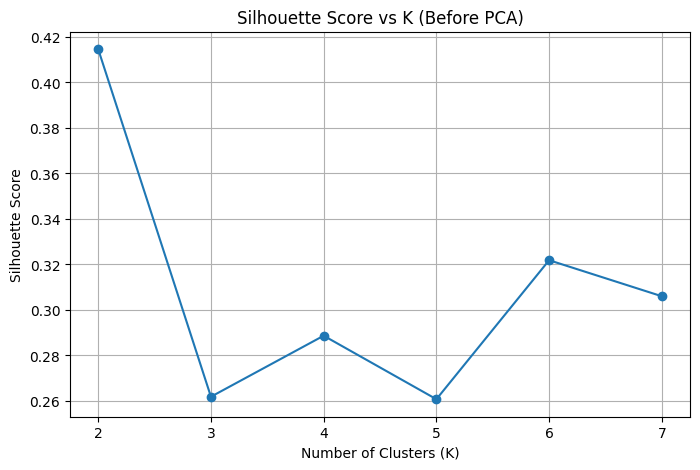

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(k_range, sil_before, marker='o')
plt.title("Silhouette Score vs K (Before PCA)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()


In [ ]:
# ================================
# STEP 8: Apply PCA
# ================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Retained:", sum(pca.explained_variance_ratio_))


Explained Variance Ratio: [0.19596001 0.14266654]
Total Variance Retained: 0.3386265478360082


In [ ]:
# ================================
# STEP 9: FAST Silhouette AFTER PCA
# ================================

import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 8)
sil_after = []

# Sample size (adjust if needed)
sample_size = 2000

if len(X_pca) > sample_size:
    indices = np.random.choice(len(X_pca), sample_size, replace=False)
    X_sample_pca = X_pca[indices]
else:
    X_sample_pca = X_pca

print("\nSilhouette Scores AFTER PCA:\n")

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_sample_pca)

    score = silhouette_score(X_sample_pca, labels)
    sil_after.append(score)

    print(f"K = {k} → {score:.4f}")



Silhouette Scores AFTER PCA:

K = 2 → 0.6403
K = 3 → 0.5284
K = 4 → 0.5391
K = 5 → 0.4899
K = 6 → 0.4518
K = 7 → 0.4519


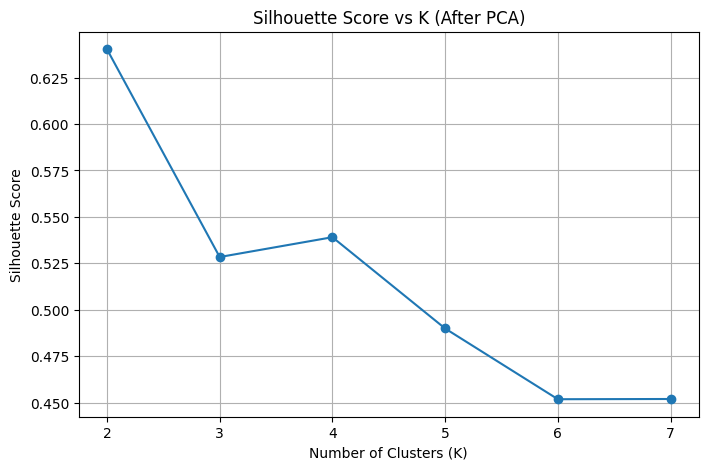

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(k_range, sil_after, marker='o')
plt.title("Silhouette Score vs K (After PCA)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()


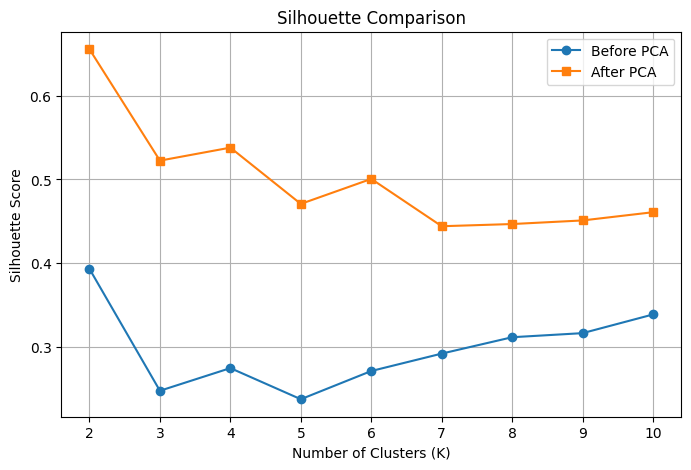

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(k_range, sil_before, marker='o', label='Before PCA')
plt.plot(k_range, sil_after, marker='s', label='After PCA')

plt.title("Silhouette Comparison")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# ================================
# FINAL MODEL (Before PCA) - K=4 (FAST)
# ================================

kmeans_before = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_before = kmeans_before.fit_predict(X_scaled)

# Use sampling to speed up silhouette
score_before = silhouette_score(
    X_scaled,
    labels_before,
    sample_size=2000,   # adjust if needed
    random_state=42
)

print("Final Silhouette Score (Before PCA, K=4):", round(score_before, 4))


Final Silhouette Score (Before PCA, K=4): 0.273


In [ ]:
# ================================
# FINAL MODEL (After PCA) - K=4 (FAST)
# ================================

kmeans_after = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_after = kmeans_after.fit_predict(X_pca)

# Fast silhouette using sampling
score_after = silhouette_score(
    X_pca,
    labels_after,
    sample_size=2000,   # reduce if still slow
    random_state=42
)

print("Final Silhouette Score (After PCA, K=4):", round(score_after, 4))


Final Silhouette Score (After PCA, K=4): 0.5342


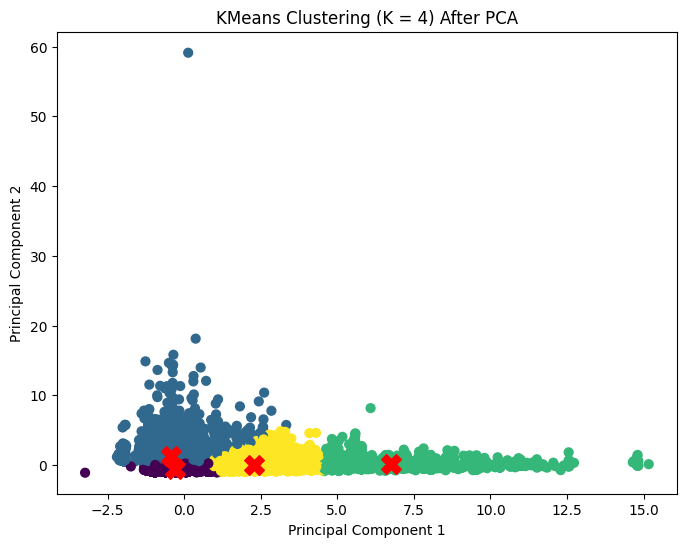

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            c=labels_after, cmap='viridis', s=40)

plt.scatter(kmeans_after.cluster_centers_[:, 0],
            kmeans_after.cluster_centers_[:, 1],
            c='red', marker='X', s=200)

plt.title("KMeans Clustering (K = 4) After PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


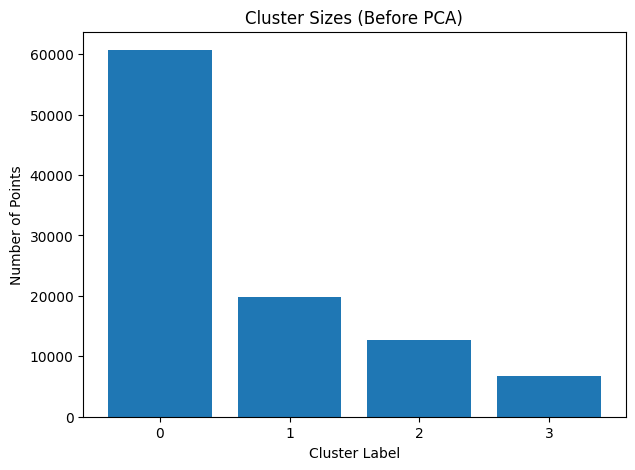

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Count points in each cluster
unique_before, counts_before = np.unique(labels_before, return_counts=True)

plt.figure(figsize=(7,5))
plt.bar(unique_before, counts_before)
plt.title("Cluster Sizes (Before PCA)")
plt.xlabel("Cluster Label")
plt.ylabel("Number of Points")
plt.xticks(unique_before)
plt.show()


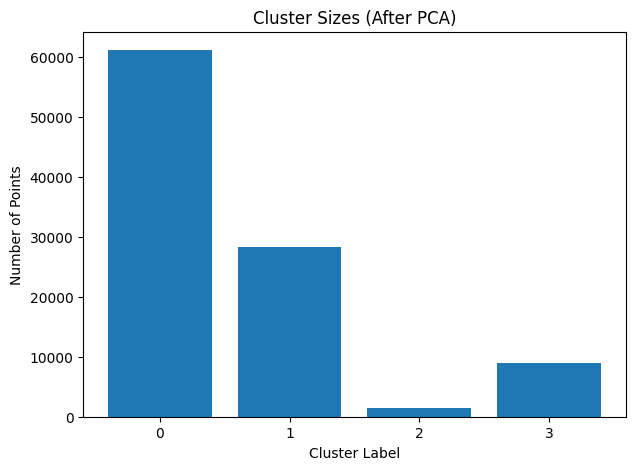

In [ ]:
unique_after, counts_after = np.unique(labels_after, return_counts=True)

plt.figure(figsize=(7,5))
plt.bar(unique_after, counts_after)
plt.title("Cluster Sizes (After PCA)")
plt.xlabel("Cluster Label")
plt.ylabel("Number of Points")
plt.xticks(unique_after)
plt.show()


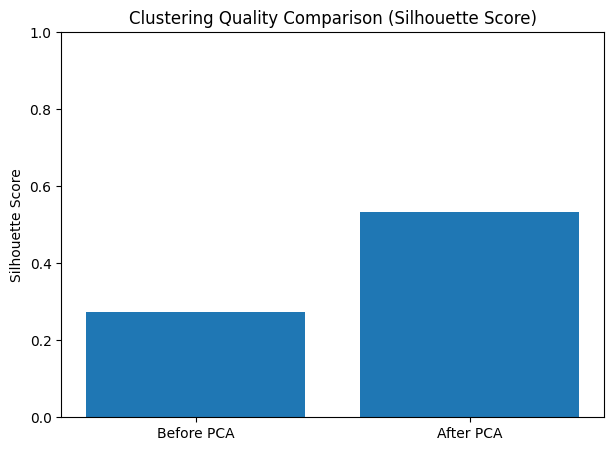

Silhouette Before PCA : 0.273
Silhouette After PCA  : 0.5342


In [ ]:
# Put both scores in lists
models = ["Before PCA", "After PCA"]
scores = [score_before, score_after]

plt.figure(figsize=(7,5))
plt.bar(models, scores)
plt.title("Clustering Quality Comparison (Silhouette Score)")
plt.ylabel("Silhouette Score")
plt.ylim(0, 1)
plt.show()

print("Silhouette Before PCA :", round(score_before, 4))
print("Silhouette After PCA  :", round(score_after, 4))
